# ДЗ 8: Multi-Head Linear Attention (MHLA) vs standard MHA Transformer

Baseline: Transformer encoder в `hw05` (`nn.TransformerEncoderLayer`).

Модель: Копируем `hw05`, но добавляем MHLA

Задача: по нуклеотидной последовательности предсказать для каждой позиции один из трёх классов — `unpaired` (неспаренная), `open` (открывающая скобка), `close` (закрывающая скобка).

## 1. Загрузка и подготовка данных

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch import nn
from datasets import load_dataset
import os
import random
import time
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

Словарь из 5 нуклеотидов (A, U, G, C, N) + PAD-токен. Разметка dot-bracket → три класса позиций.

In [3]:
NUC_VOCAB = {'A': 0, 'U': 1, 'G': 2, 'C': 3, 'T': 1, 'N': 4, '<PAD>': 5}
LABEL_VOCAB = {'unpaired': 0, 'open': 1, 'close': 2}

PAD_TOKEN = NUC_VOCAB['<PAD>']
PAD_LABEL = -100


def dot_bracket_to_pairs(db: str) -> list:
    stack, pairs = [], []
    for i, c in enumerate(db):
        if c == '(':
            stack.append(i)
        elif c == ')' and stack:
            pairs.append((stack.pop() + 1, i + 1))
    return pairs


def pairs_to_labels(pairs: list, length: int) -> torch.Tensor:
    labels = torch.zeros(length, dtype=torch.long)
    for i, j in pairs:
        if 1 <= i <= length and 1 <= j <= length:
            labels[i - 1] = 1
            labels[j - 1] = 2
    return labels


def preprocess(row):
    seq = row['sequence'].upper().replace('T', 'U')
    db = row['secondary_structure']
    L = len(seq)
    pairs = dot_bracket_to_pairs(db)
    return {
        'tokens': [NUC_VOCAB.get(c, NUC_VOCAB['N']) for c in seq],
        'labels': pairs_to_labels(pairs, L).tolist(),
        'length': L,
    }


hf = load_dataset("multimolecule/archiveii", split="test")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/4.01k [00:00<?, ?B/s]

test.parquet:   0%|          | 0.00/283k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/3975 [00:00<?, ? examples/s]

Фильтрация последовательностей по длине (10–512) и токенизация.

In [4]:
hf_data = hf.filter(lambda x: 10 <= len(x['sequence']) <= 512, num_proc=8).map(preprocess, num_proc=8)

Filter (num_proc=8):   0%|          | 0/3975 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/3865 [00:00<?, ? examples/s]

In [5]:
hf_data.set_format('torch', columns=['tokens', 'labels', 'length'])
hf_data = hf_data.class_encode_column("family")

Casting to class labels:   0%|          | 0/3865 [00:00<?, ? examples/s]

Стратифицированное разбиение по семействам РНК: ~70% train, ~15% val, ~15% test.

In [6]:
split1 = hf_data.train_test_split(test_size=0.15, seed=42, stratify_by_column='family')
test_ds = split1['test']
split2 = split1['train'].train_test_split(test_size=0.176, seed=42, stratify_by_column='family')
train_ds, val_ds = split2['train'], split2['test']

## 2. Модель

In [7]:
class RotaryEmbedding(nn.Module):
    def __init__(self, dim, max_len, base=10000.0):
        super().__init__()
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        t = torch.arange(max_len).float()
        freqs = torch.einsum('i,j->ij', t, inv_freq)
        emb = torch.cat([freqs, freqs], dim=-1)
        self.register_buffer('cos', emb.cos(), persistent=False)
        self.register_buffer('sin', emb.sin(), persistent=False)

    def forward(self, seq_len):
        return self.cos[:seq_len], self.sin[:seq_len]


def rotate_half(x):
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat([-x2, x1], dim=-1)


def apply_rope(x, cos, sin):
    return x * cos + rotate_half(x) * sin


class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(dim))
        self.eps = eps

    def forward(self, x):
        scale = x.pow(2).mean(-1, keepdim=True).add(self.eps).rsqrt()
        return x * scale * self.weight

In [8]:
class MultiHeadLinearAttention(nn.Module):
    def __init__(self, d_model, num_heads, chunk_size, max_len):
        super().__init__()
        self.num_heads = num_heads
        self.chunk_size = chunk_size
        self.n_chunks = max_len // chunk_size
        self.head_v_dim = d_model // num_heads
        self.head_k_dim = (d_model // 2) // num_heads
        self.key_dim = self.head_k_dim * num_heads

        self.q_proj = nn.Linear(d_model, self.key_dim, bias=False)
        self.k_proj = nn.Linear(d_model, self.key_dim, bias=False)
        self.v_proj = nn.Linear(d_model, d_model, bias=False)
        self.g_proj = nn.Linear(d_model, d_model, bias=False)
        self.o_proj = nn.Linear(d_model, d_model, bias=False)

        self.rope = RotaryEmbedding(self.head_k_dim, max_len)
        self.norm = RMSNorm(self.head_v_dim)

        idx = torch.arange(self.n_chunks).float()
        init_m = 1.0 / (1.0 + (idx[:, None] - idx[None, :]).abs())
        self.mixing_logits = nn.Parameter(init_m)

    def get_mixing_matrix(self):
        m = 0.5 * (self.mixing_logits + self.mixing_logits.transpose(0, 1))
        return m.clamp(0.0, 1.0)

    def project_qk(self, x):
        B, L, _ = x.shape
        q = self.q_proj(x).view(B, L, self.num_heads, self.head_k_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, L, self.num_heads, self.head_k_dim).transpose(1, 2)
        q, k = F.relu(q), F.relu(k)
        cos, sin = self.rope(L)
        return apply_rope(q, cos, sin), apply_rope(k, cos, sin)

    def forward(self, x, key_padding_mask=None):
        B, L, _ = x.shape
        H, n_chunks, cs = self.num_heads, self.n_chunks, self.chunk_size

        q, k = self.project_qk(x)
        v = self.v_proj(x).view(B, L, H, self.head_v_dim).transpose(1, 2)

        if key_padding_mask is not None:
            keep = (~key_padding_mask).float().view(B, 1, L, 1)
            k, v = k * keep, v * keep

        q_c = q.reshape(B, H, n_chunks, cs, self.head_k_dim)
        k_c = k.reshape(B, H, n_chunks, cs, self.head_k_dim)
        v_c = v.reshape(B, H, n_chunks, cs, self.head_v_dim)

        s = torch.einsum('bhcsd,bhcse->bhcde', k_c, v_c)
        m = self.get_mixing_matrix()
        s_mixed = torch.einsum('ij,bhjde->bhide', m, s)
        o = torch.einsum('bhcsd,bhcde->bhcse', q_c, s_mixed)
        o = o.reshape(B, H, L, self.head_v_dim)

        g = self.g_proj(x).view(B, L, H, self.head_v_dim).transpose(1, 2)
        o = self.norm(o) * F.silu(g)
        o = o.transpose(1, 2).reshape(B, L, H * self.head_v_dim)
        return self.o_proj(o)

In [9]:
class MHLAEncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, dim_feedforward, chunk_size, max_len, dropout=0.2):
        super().__init__()
        self.self_attn = MultiHeadLinearAttention(d_model, num_heads, chunk_size, max_len)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        x = self.norm1(x + self.dropout1(self.self_attn(x, key_padding_mask)))
        ff = self.linear2(self.dropout(F.relu(self.linear1(x))))
        return self.norm2(x + self.dropout2(ff))


class RNAStructTransformerMHLA(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, n_layers, n_classes, chunk_size, max_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=5)
        self.layers = nn.ModuleList([
            MHLAEncoderLayer(d_model, num_heads, d_model * 4, chunk_size, max_len)
            for _ in range(n_layers)
        ])
        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, n_classes),
        )

    def forward(self, tokens, src_key_padding_mask=None):
        x = self.embedding(tokens)
        for layer in self.layers:
            x = layer(x, src_key_padding_mask)
        return self.classifier(x).permute(0, 2, 1)

In [10]:
BATCH_SIZE = 64
NUM_EPOCHS = 130
LR = 5e-4
WEIGHT_DECAY = 1e-2

EMBED_DIM = 128
NUM_HEADS = 8
NUM_LAYERS = 4
NUM_CLASSES = 3
MAX_LEN = 512
CHUNK_SIZE = 64

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [11]:
def collate_fn(batch):
    B = len(batch)
    tokens = torch.full((B, MAX_LEN), PAD_TOKEN, dtype=torch.long)
    labels = torch.full((B, MAX_LEN), PAD_LABEL, dtype=torch.long)
    lengths = torch.tensor([b['length'] for b in batch])
    for i, b in enumerate(batch):
        L = b['length']
        tokens[i, :L] = b['tokens']
        labels[i, :L] = b['labels']
    mask = torch.arange(MAX_LEN).unsqueeze(0) >= lengths.unsqueeze(1)
    return {'tokens': tokens, 'labels': labels, 'lengths': lengths, 'src_key_padding_mask': mask}


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)

In [13]:
mhla_model_for_count = RNAStructTransformerMHLA(
    vocab_size=len(NUC_VOCAB), d_model=EMBED_DIM, num_heads=NUM_HEADS, n_layers=NUM_LAYERS,
    n_classes=NUM_CLASSES, chunk_size=CHUNK_SIZE, max_len=MAX_LEN,
)
n_params_mhla = sum(p.numel() for p in mhla_model_for_count.parameters())
print(f"MHLA params: {n_params_mhla:,}")

MHLA params: 800,707


## 3. Обучение

In [14]:
def make_loss_fn(dataset):
    counts = torch.zeros(3)
    for s in dataset:
        labels = s['labels']
        for c in range(3):
            counts[c] += (labels == c).sum()

    weights = counts.sum() / (3 * counts)
    weights /= weights.sum()
    print(f"Class weights - unpaired: {weights[0]:.3f} | open: {weights[1]:.3f} | close: {weights[2]:.3f}")
    return torch.nn.CrossEntropyLoss(weight=weights, ignore_index=PAD_LABEL)

In [15]:
@torch.no_grad()
def update_confusion(counts_3, preds, labels):
    valid = labels != PAD_LABEL
    t = labels[valid]
    p = preds[valid]
    bins = torch.bincount(t * 3 + p, minlength=9).reshape(3, 3)
    counts_3 += bins.cpu()


def metrics_from_cm(cm):
    cm = cm.float()
    tp = cm[1:, 1:].sum()
    fp = cm[0, 1:].sum()
    fn = cm[1:, 0].sum()
    tn = cm[0, 0]
    sens = tp / (tp + fn + 1e-8)
    ppv = tp / (tp + fp + 1e-8)
    f1 = 2 * sens * ppv / (sens + ppv + 1e-8)
    num = tp * tn - fp * fn
    den = ((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)).sqrt()
    mcc = num / (den + 1e-8)
    f1s = []
    for c in range(3):
        tpc = cm[c, c]
        prec = tpc / (cm[:, c].sum() + 1e-8)
        rec = tpc / (cm[c, :].sum() + 1e-8)
        f1s.append((2 * prec * rec / (prec + rec + 1e-8)).item())
    return {'f1': f1.item(), 'sensitivity': sens.item(), 'ppv': ppv.item(),
            'mcc': mcc.item(), 'f1_macro': float(np.mean(f1s))}


def run_epoch(model, loader, criterion, device, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()

    counts_3 = torch.zeros(3, 3, dtype=torch.long)
    total_loss, n_samples = 0.0, 0

    grad_ctx = torch.enable_grad() if train else torch.no_grad()
    with grad_ctx:
        for batch in loader:
            tokens = batch['tokens'].to(device, non_blocking=True)
            labels = batch['labels'].to(device, non_blocking=True)
            mask = batch['src_key_padding_mask'].to(device, non_blocking=True)
            B = tokens.size(0)

            logits = model(tokens, src_key_padding_mask=mask)
            loss = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * B
            n_samples += B
            update_confusion(counts_3, logits.detach().argmax(1), labels)

    metrics = metrics_from_cm(counts_3)
    metrics['loss'] = total_loss / n_samples
    return metrics

In [16]:
model = RNAStructTransformerMHLA(
    vocab_size=len(NUC_VOCAB), d_model=EMBED_DIM, num_heads=NUM_HEADS, n_layers=NUM_LAYERS,
    n_classes=NUM_CLASSES, chunk_size=CHUNK_SIZE, max_len=MAX_LEN,
).to(device)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, patience=4, factor=0.1, min_lr=1e-11)
criterion = make_loss_fn(train_ds).to(device)

Class weights - unpaired: 0.242 | open: 0.379 | close: 0.379


In [17]:
best_val_metric = float('-inf')
best_model_state = None
patience, patience_counter = 10, 0
train_history: list[dict[str, float]] = []
val_history: list[dict[str, float]] = []


for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_metrics = run_epoch(model, train_loader, criterion, device, optimizer)
    val_metrics = run_epoch(model, val_loader, criterion, device)
    scheduler.step(val_metrics['loss'])
    elapsed = time.time() - t0

    train_metrics['epoch'] = val_metrics['epoch'] = epoch
    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_metrics['loss']:.4f}  F1: {train_metrics['f1']:.4f} F1M: {train_metrics['f1_macro']:.4f} | "
          f"Val Loss: {val_metrics['loss']:.4f}  F1: {val_metrics['f1']:.4f}  MCC {val_metrics['mcc']:.4f} F1M: {val_metrics['f1_macro']:.4f} | "
          f"{elapsed:.1f}s")

    if val_metrics['mcc'] > best_val_metric:
        best_val_metric = val_metrics['mcc']
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

assert best_model_state is not None
model.load_state_dict(best_model_state)

Epoch  1/130 | Train Loss: 0.9471  F1: 0.7196 F1M: 0.5232 | Val Loss: 0.8736  F1: 0.7263  MCC 0.2703 F1M: 0.5592 | 6.2s
Epoch  2/130 | Train Loss: 0.8459  F1: 0.7311 F1M: 0.5716 | Val Loss: 0.7973  F1: 0.7446  MCC 0.3153 F1M: 0.5939 | 4.7s
Epoch  3/130 | Train Loss: 0.7861  F1: 0.7450 F1M: 0.6011 | Val Loss: 0.7492  F1: 0.7565  MCC 0.3545 F1M: 0.6228 | 4.8s
Epoch  4/130 | Train Loss: 0.7392  F1: 0.7561 F1M: 0.6239 | Val Loss: 0.7108  F1: 0.7651  MCC 0.3856 F1M: 0.6401 | 4.7s
Epoch  5/130 | Train Loss: 0.7035  F1: 0.7660 F1M: 0.6412 | Val Loss: 0.6696  F1: 0.7762  MCC 0.4218 F1M: 0.6629 | 4.7s
Epoch  6/130 | Train Loss: 0.6681  F1: 0.7759 F1M: 0.6612 | Val Loss: 0.6449  F1: 0.7848  MCC 0.4411 F1M: 0.6699 | 4.8s
Epoch  7/130 | Train Loss: 0.6411  F1: 0.7849 F1M: 0.6774 | Val Loss: 0.6193  F1: 0.7942  MCC 0.4730 F1M: 0.6893 | 4.7s
Epoch  8/130 | Train Loss: 0.6188  F1: 0.7903 F1M: 0.6900 | Val Loss: 0.5892  F1: 0.7995  MCC 0.4942 F1M: 0.7056 | 4.8s
Epoch  9/130 | Train Loss: 0.5930  F1: 0

<All keys matched successfully>

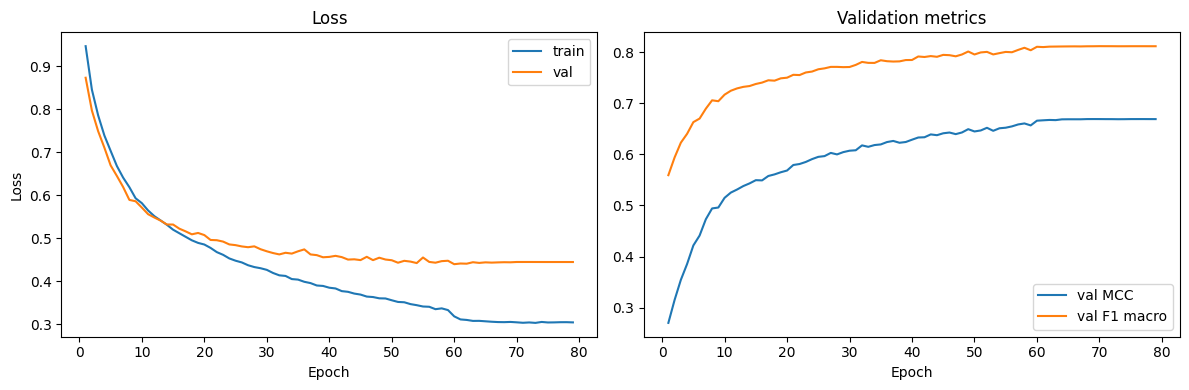

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = [m['epoch'] for m in train_history]
axes[0].plot(epochs, [m['loss'] for m in train_history], label='train')
axes[0].plot([m['epoch'] for m in val_history], [m['loss'] for m in val_history], label='val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].set_title('Loss')

axes[1].plot([m['epoch'] for m in val_history], [m['mcc'] for m in val_history], label='val MCC')
axes[1].plot([m['epoch'] for m in val_history], [m['f1_macro'] for m in val_history], label='val F1 macro')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].set_title('Validation metrics')
plt.tight_layout()
plt.show()

## 4. Оценка на тесте

In [20]:
HW05_MHA_TEST_METRICS = {
    'loss': 0.441, 'f1': 0.855, 'sensitivity': 0.928, 'ppv': 0.794, 'mcc': 0.646, 'f1_macro': 0.796,
}

mhla_test_metrics = run_epoch(model, test_loader, criterion, device)

comparison = pd.DataFrame([
    {'model': 'MHA (HW05)', 'params': 802_435, **HW05_MHA_TEST_METRICS},
    {'model': 'MHLA', 'params': n_params_mhla, **mhla_test_metrics},
]).set_index('model')
comparison

,params,loss,f1,sensitivity,ppv,mcc,f1_macro
model,,,,,,,
MHA (HW05),802435,0.441000,0.855000,0.928000,0.794000,0.646000,0.796000
MHLA,800707,0.429796,0.866801,0.936591,0.806691,0.675855,0.817022


## 5. Визуализация внимания

In [24]:
candidates = []
for i in range(len(test_ds)):
    item = test_ds[i]
    L = item['length'].item()
    if 50 <= L <= 80:
        labels = item['labels'][:L]
        ratio = (labels != 0).float().mean().item()
        candidates.append((ratio, i, L))
candidates.sort(reverse=True)
_, sample_idx, L = candidates[0]
print(f"sample_idx={sample_idx}, L={L}, pairing ratio={candidates[0][0]:.2f}")

sample_idx=493, L=65, pairing ratio=0.62


Для MHLA, матрица внимания  $A[i,j] = \phi(q_i)\cdot\phi(k_j)\cdot M[c_i,c_j]$ восстановлена с помощью формулы смешивания чанков

In [25]:
@torch.no_grad()
def compute_mhla_attention(attn_module, x, key_padding_mask):
    B, Lp, _ = x.shape
    cs = attn_module.chunk_size
    q, k = attn_module.project_qk(x)
    m = attn_module.get_mixing_matrix()
    chunk_ids = torch.arange(Lp, device=x.device) // cs
    m_full = m[chunk_ids][:, chunk_ids]
    scores = torch.einsum('bhid,bhjd->bhij', q, k) * m_full
    if key_padding_mask is not None:
        scores = scores.masked_fill(key_padding_mask[:, None, None, :], 0.0)
    return scores[0]


@torch.no_grad()
def get_layer_attentions(model, tokens, mask):
    x = model.embedding(tokens)
    attns = []
    for layer in model.layers:
        attns.append(compute_mhla_attention(layer.self_attn, x, mask).cpu())
        x = layer(x, mask)
    return attns


def pad_to_max_len(tokens_1d):
    padded = torch.full((1, MAX_LEN), PAD_TOKEN, dtype=torch.long)
    padded[0, :tokens_1d.size(0)] = tokens_1d
    return padded


model.eval()
sample = test_ds[sample_idx]
tokens = pad_to_max_len(sample['tokens']).to(device)
mask = (torch.arange(MAX_LEN).unsqueeze(0) >= sample['length']).to(device)

layer_attns = get_layer_attentions(model, tokens, mask)
layer_attns = [a[:, :L, :L] for a in layer_attns]

### 5.1 Карты внимания по головам

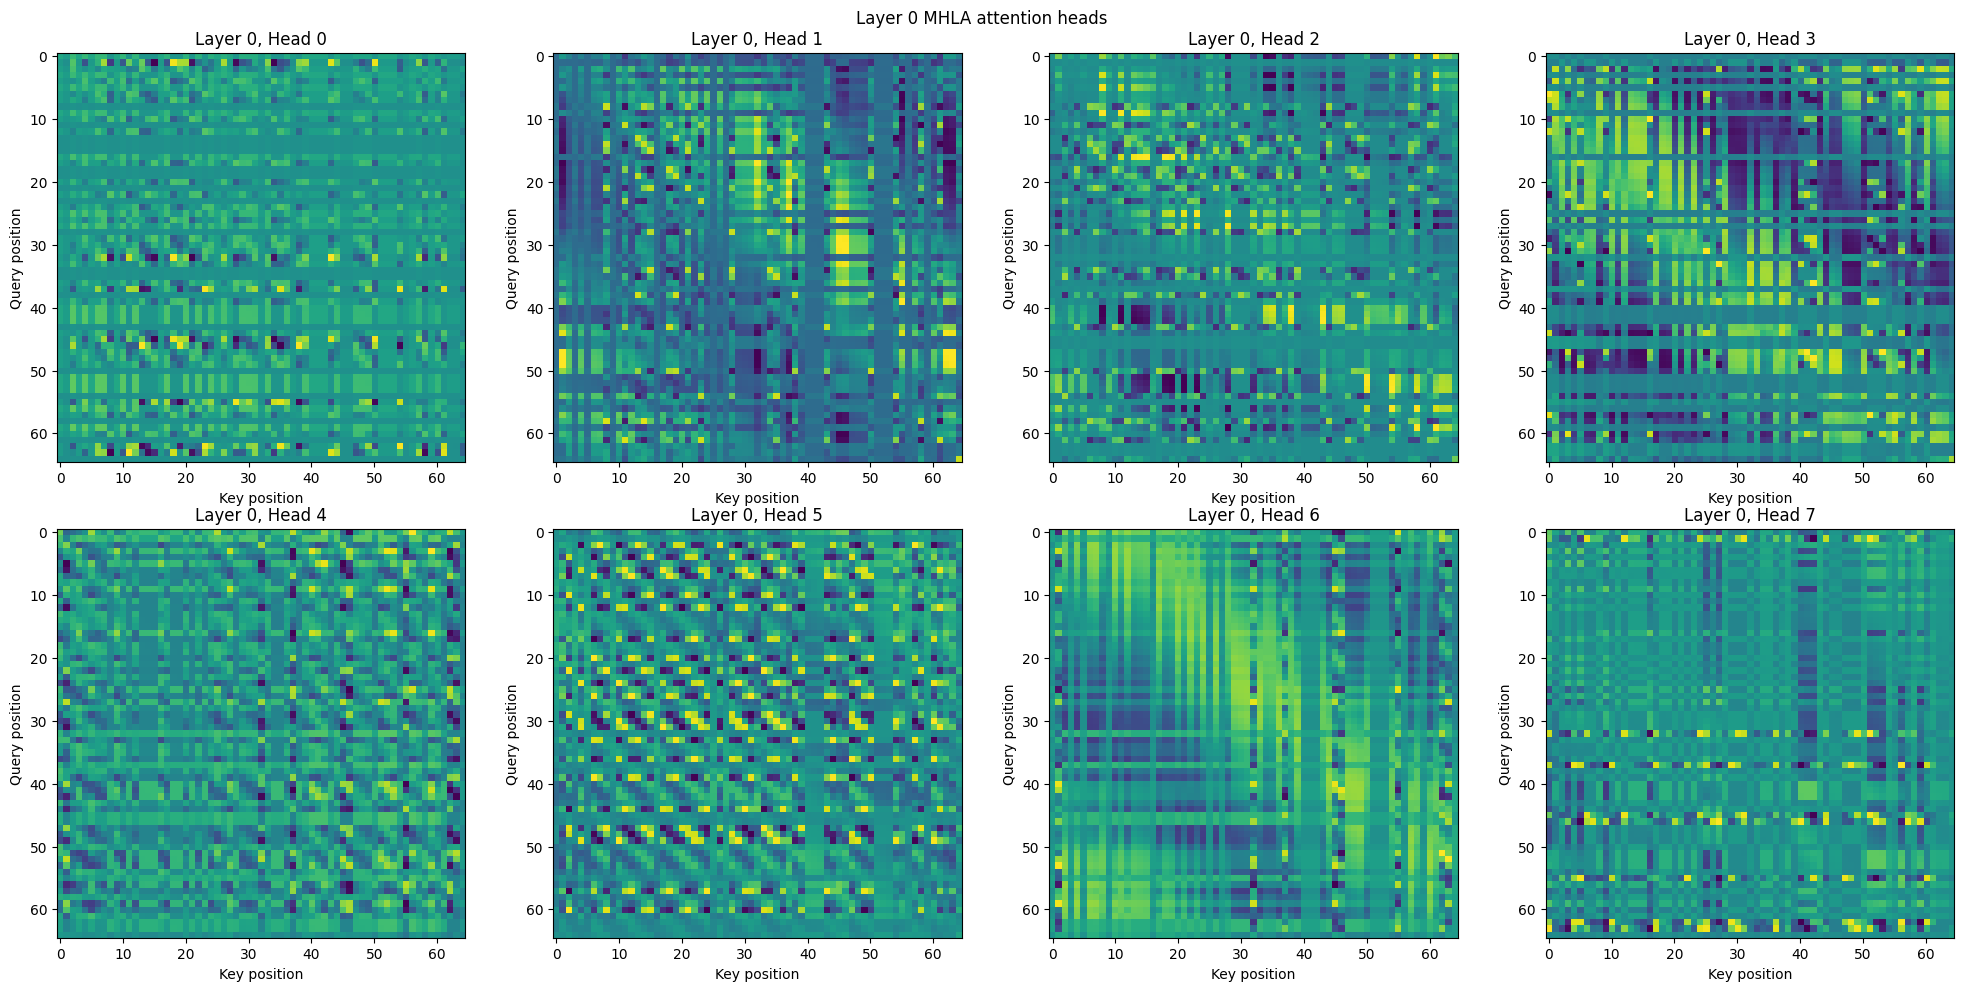

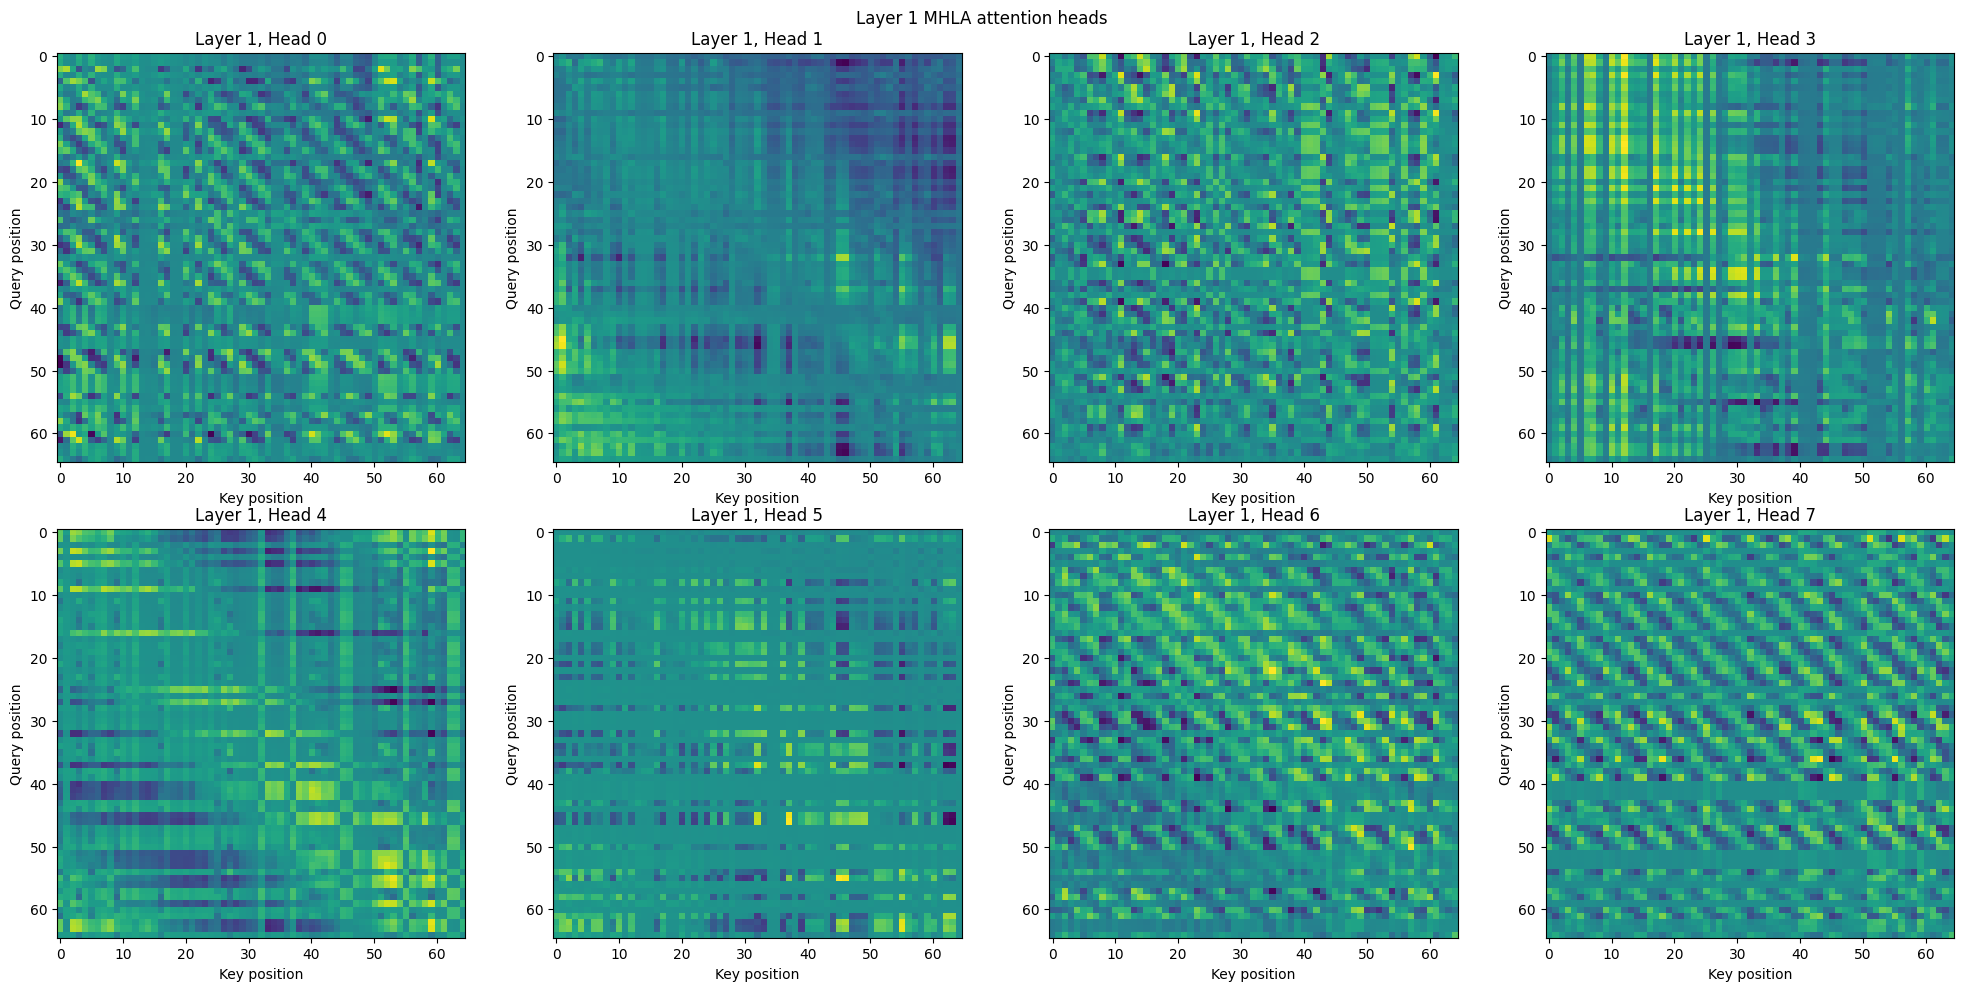

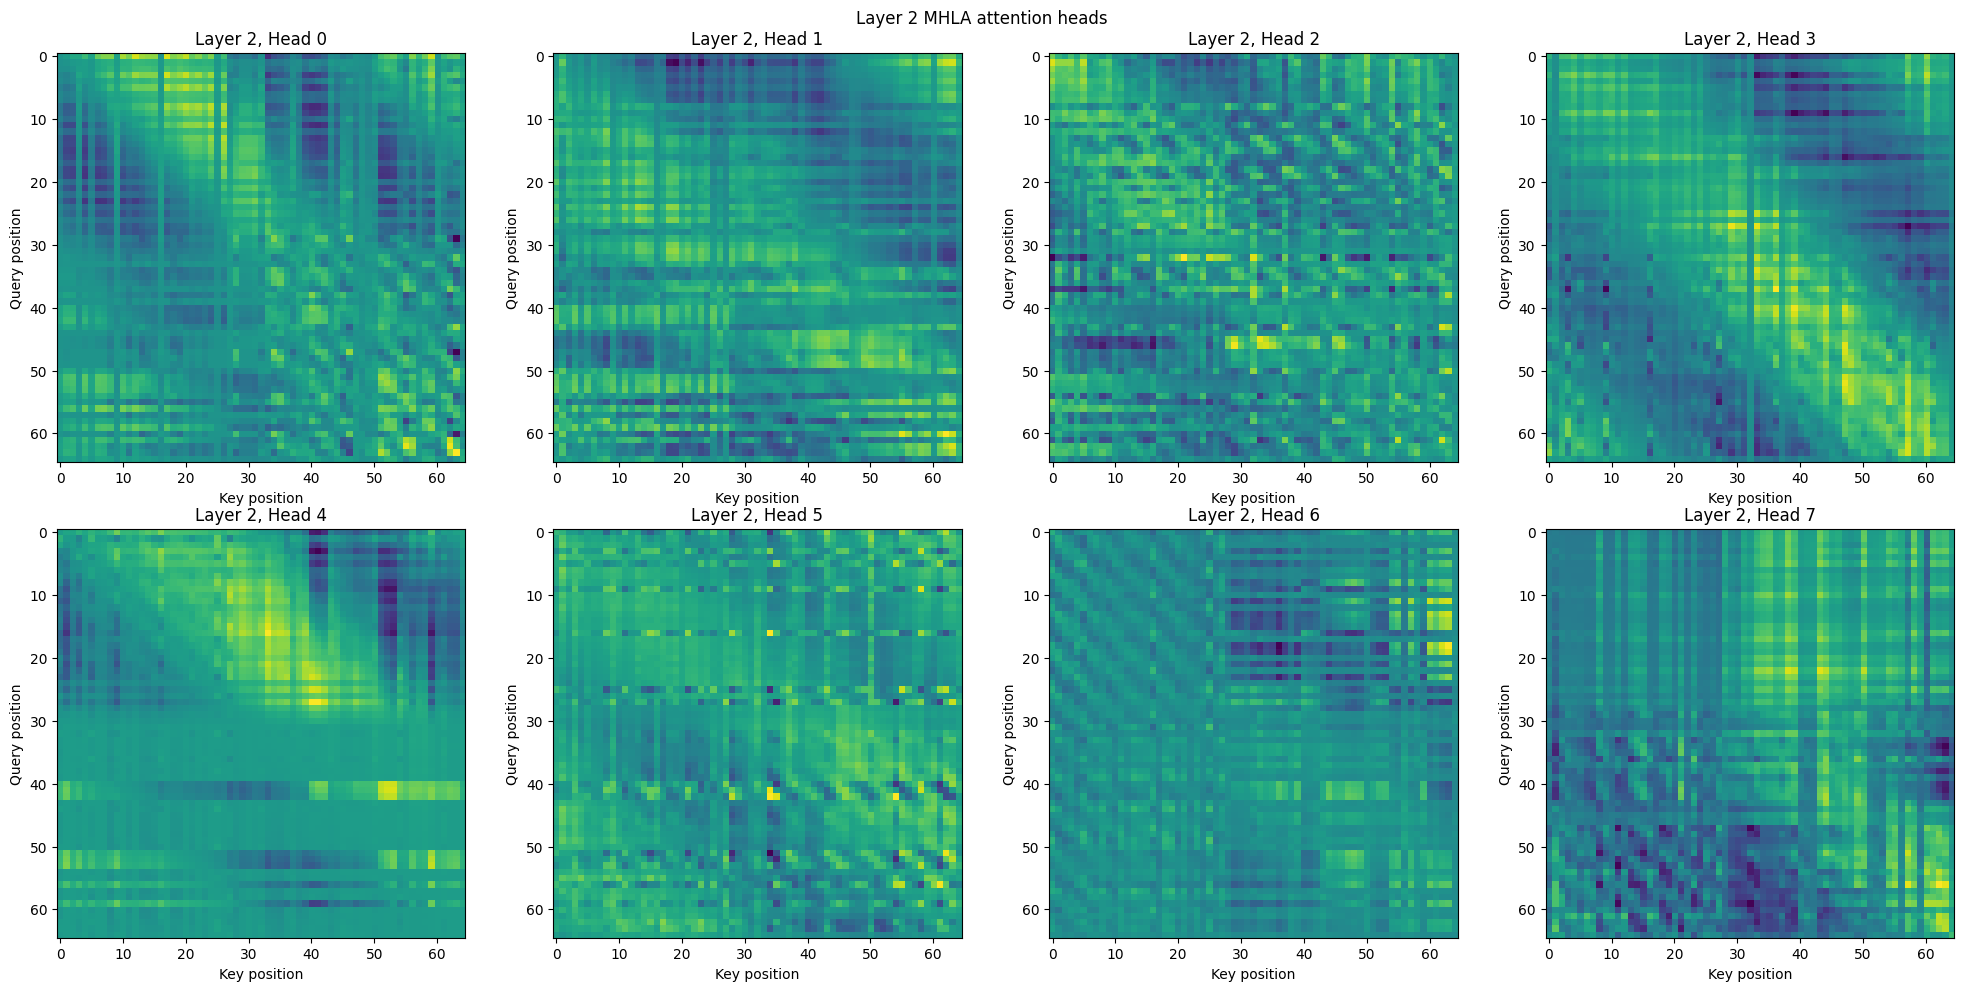

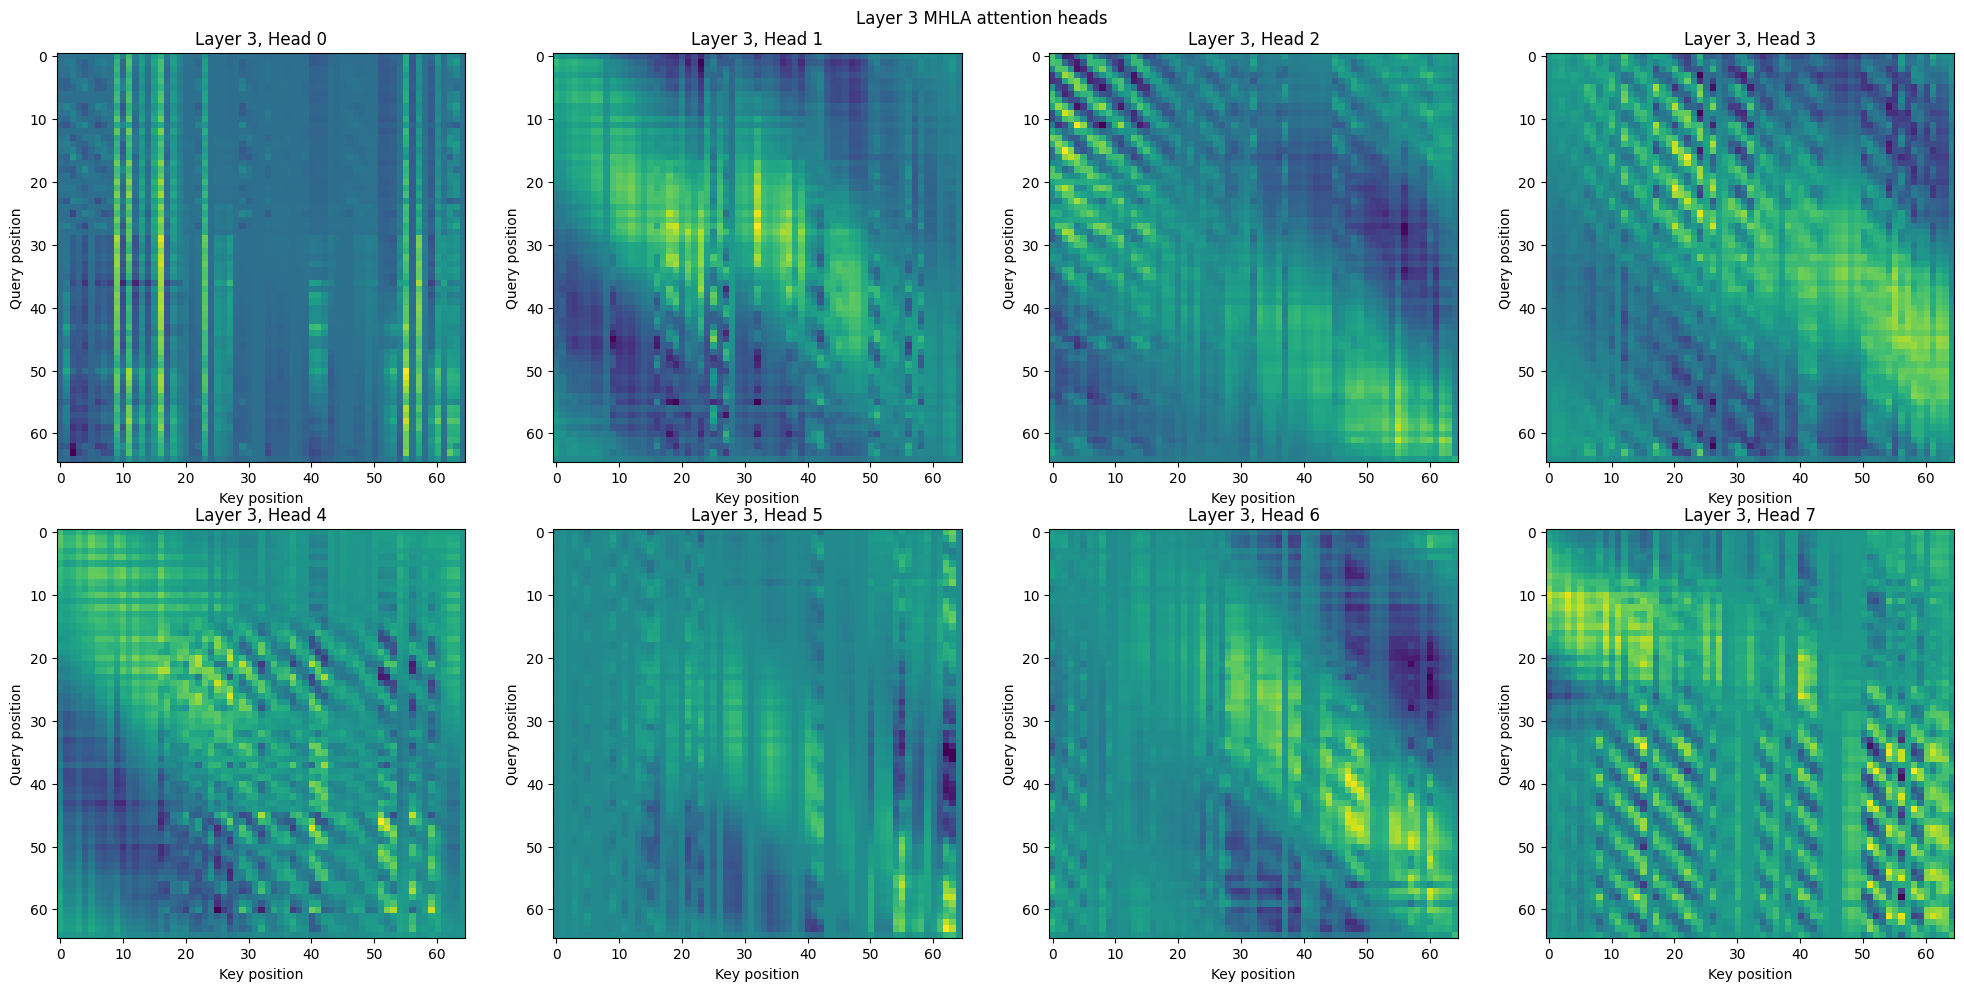

In [26]:
for layer_idx, attn in enumerate(layer_attns):
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    for head_idx, ax in enumerate(axes.flat):
        ax.imshow(attn[head_idx].numpy(), cmap='viridis', aspect='equal')
        ax.set_title(f'Layer {layer_idx}, Head {head_idx}')
        ax.set_xlabel('Key position')
        ax.set_ylabel('Query position')
    plt.suptitle(f'Layer {layer_idx} MHLA attention heads')
    plt.tight_layout()
    plt.show()

### 5.2 Сравнение внимания с контактной картой

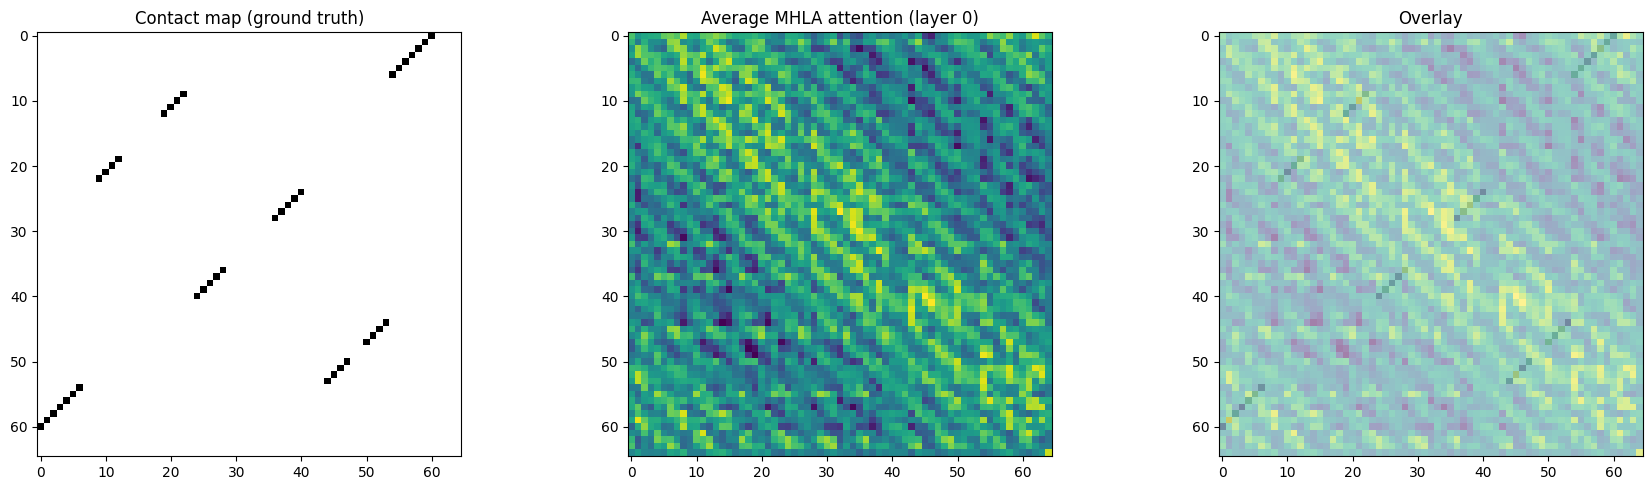

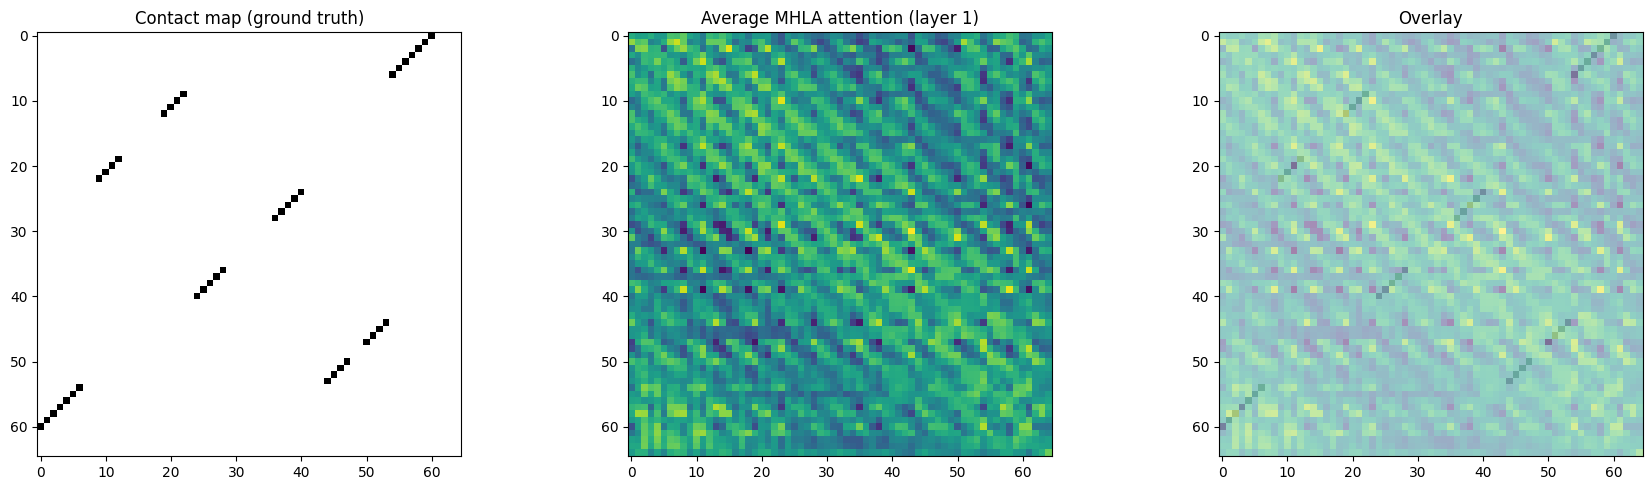

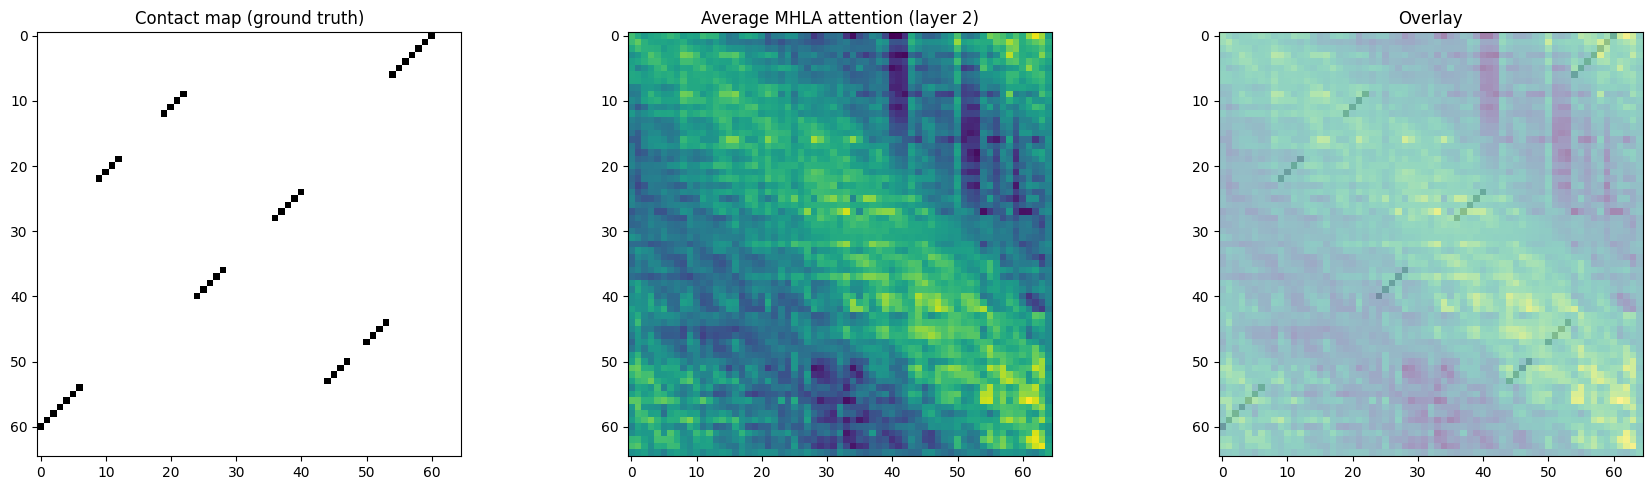

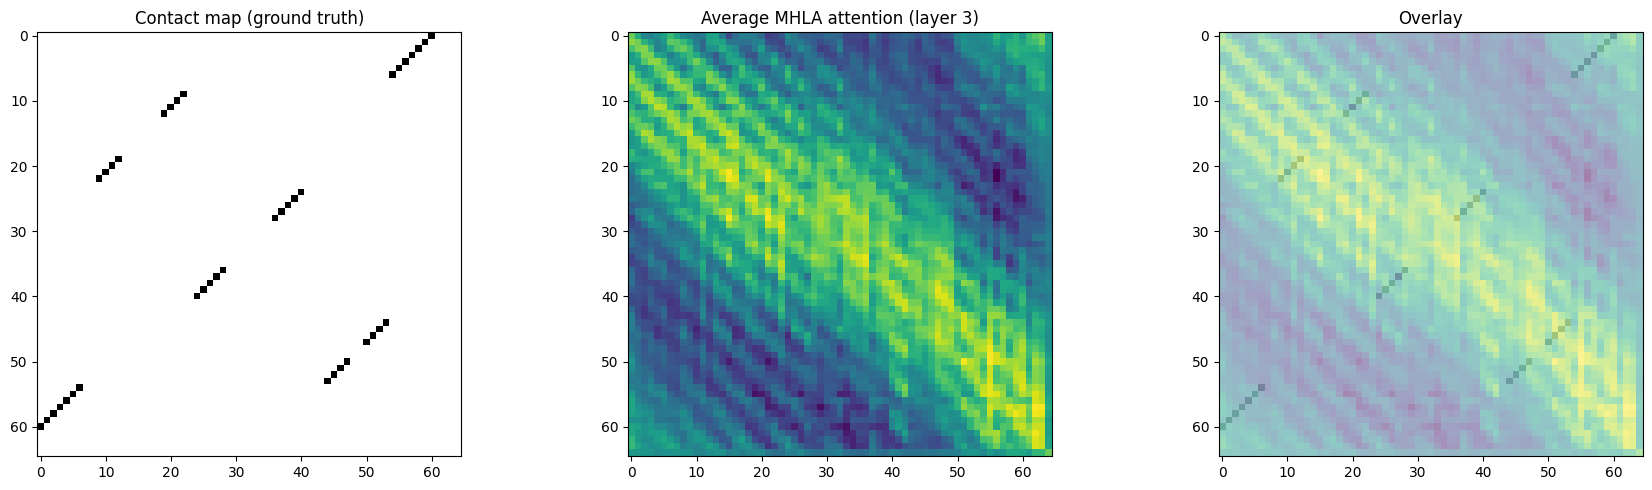

In [27]:
test_ds.reset_format()
secondary_structure = test_ds[sample_idx]['secondary_structure']
test_ds.set_format('torch', columns=['tokens', 'labels', 'length'])

pairs = dot_bracket_to_pairs(secondary_structure)
contact = torch.zeros(L, L)
for i, j in pairs:
    if 1 <= i <= L and 1 <= j <= L:
        contact[i - 1, j - 1] = contact[j - 1, i - 1] = 1.0

for layer_idx, attn in enumerate(layer_attns):
    avg_attn = attn.mean(0).numpy()
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].imshow(contact.numpy(), cmap='Greys')
    axes[0].set_title('Contact map (ground truth)')
    axes[1].imshow(avg_attn, cmap='viridis')
    axes[1].set_title(f'Average MHLA attention (layer {layer_idx})')
    axes[2].imshow(contact.numpy(), cmap='Greys', alpha=0.3)
    axes[2].imshow(avg_attn, cmap='viridis', alpha=0.5)
    axes[2].set_title('Overlay')
    plt.tight_layout()
    plt.show()

Это мне уже больше нравится. Не смотря на месиво в поголовном графике, при усреднении внимания, видно что оно ложится на места контактов.

Это лучший из всех результат соответсвия (на мой взгляд лучше оригинального трансформера)

### 5.3 Профиль внимания по расстоянию

Для MHLA $A[i,j]$ это произведение $\phi(q_i)\cdot\phi(k_j)$ и $M[c_i,c_j]$, so the distance profile is expected to show $C=64$-wide blocks on top of the smooth content-based decay.

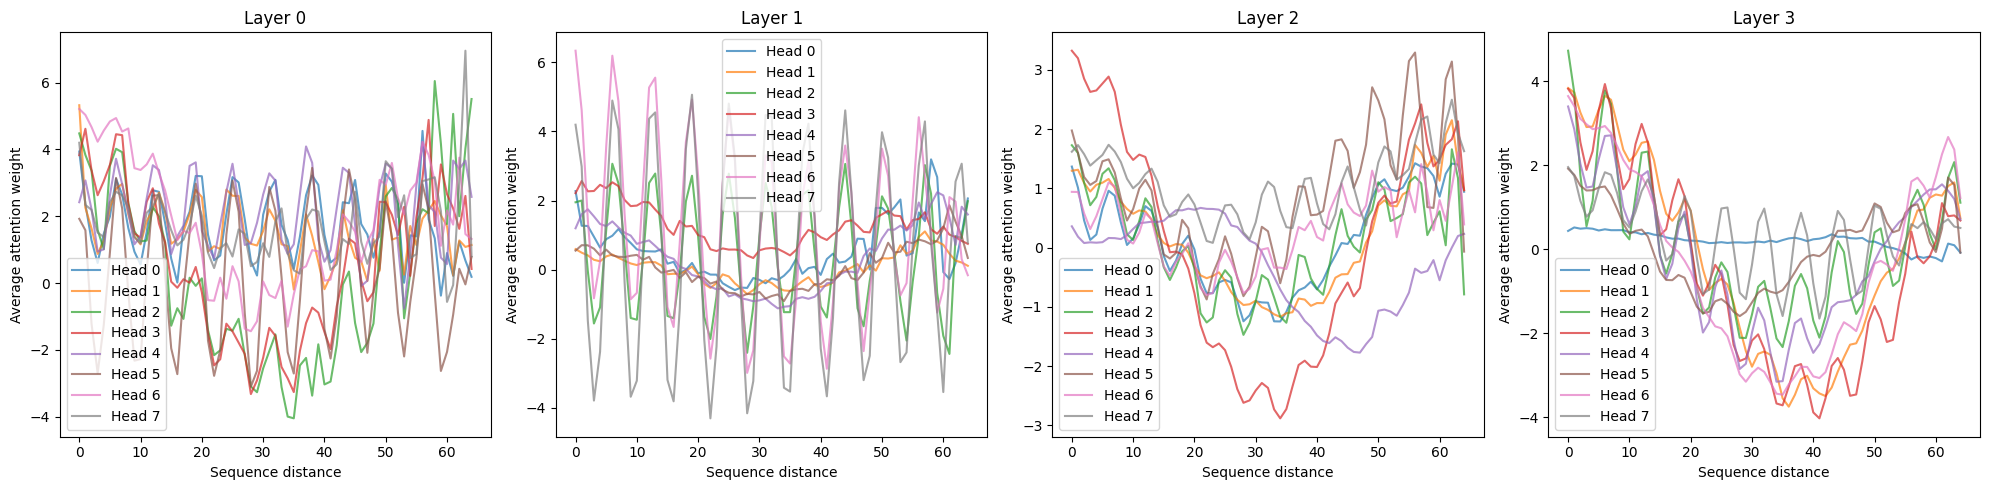

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for layer_idx, attn in enumerate(layer_attns):
    for head_idx in range(attn.size(0)):
        max_dist = L - 1
        bins = np.zeros(max_dist + 1)
        counts = np.zeros(max_dist + 1)
        for i in range(L):
            for j in range(L):
                d = abs(i - j)
                bins[d] += attn[head_idx, i, j].item()
                counts[d] += 1
        avg_weight = bins / (counts + 1e-8)
        axes[layer_idx].plot(avg_weight, label=f'Head {head_idx}', alpha=0.7)
    axes[layer_idx].set_xlabel('Sequence distance')
    axes[layer_idx].set_ylabel('Average attention weight')
    axes[layer_idx].set_title(f'Layer {layer_idx}')
    axes[layer_idx].legend()
plt.tight_layout()
plt.show()

### 5.4 Матрицы смешивания

$M[c,c'] \in [0,1]$ per layer, compared with the $1/(1+|c-c'|)$ initialization.

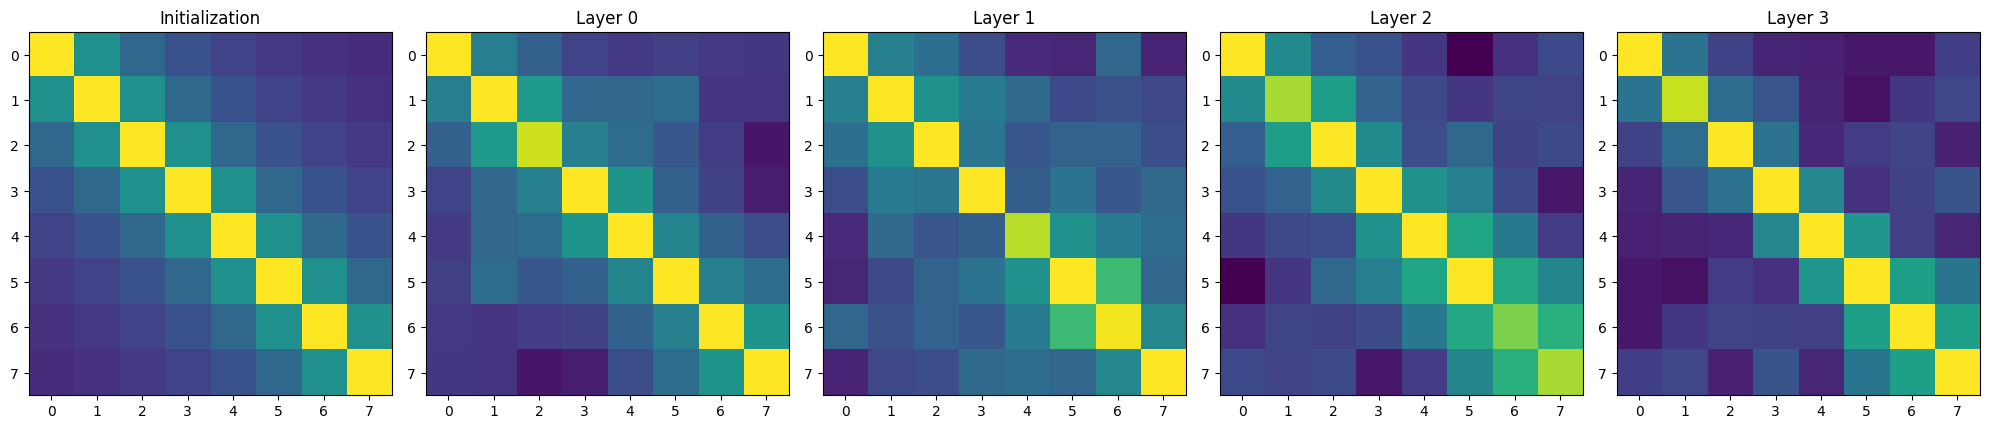

In [29]:
n_chunks = MAX_LEN // CHUNK_SIZE
idx = torch.arange(n_chunks).float()
init_m = (1.0 / (1.0 + (idx[:, None] - idx[None, :]).abs())).numpy()

fig, axes = plt.subplots(1, NUM_LAYERS + 1, figsize=(4 * (NUM_LAYERS + 1), 4))
axes[0].imshow(init_m, cmap='viridis', vmin=0, vmax=1)
axes[0].set_title('Initialization')
for layer_idx, layer in enumerate(model.layers):
    m = layer.self_attn.get_mixing_matrix().detach().cpu().numpy()
    ax = axes[layer_idx + 1]
    ax.imshow(m, cmap='viridis', vmin=0, vmax=1)
    ax.set_title(f'Layer {layer_idx}')
plt.tight_layout()
plt.show()

### 5.5 Предсказание vs ground truth

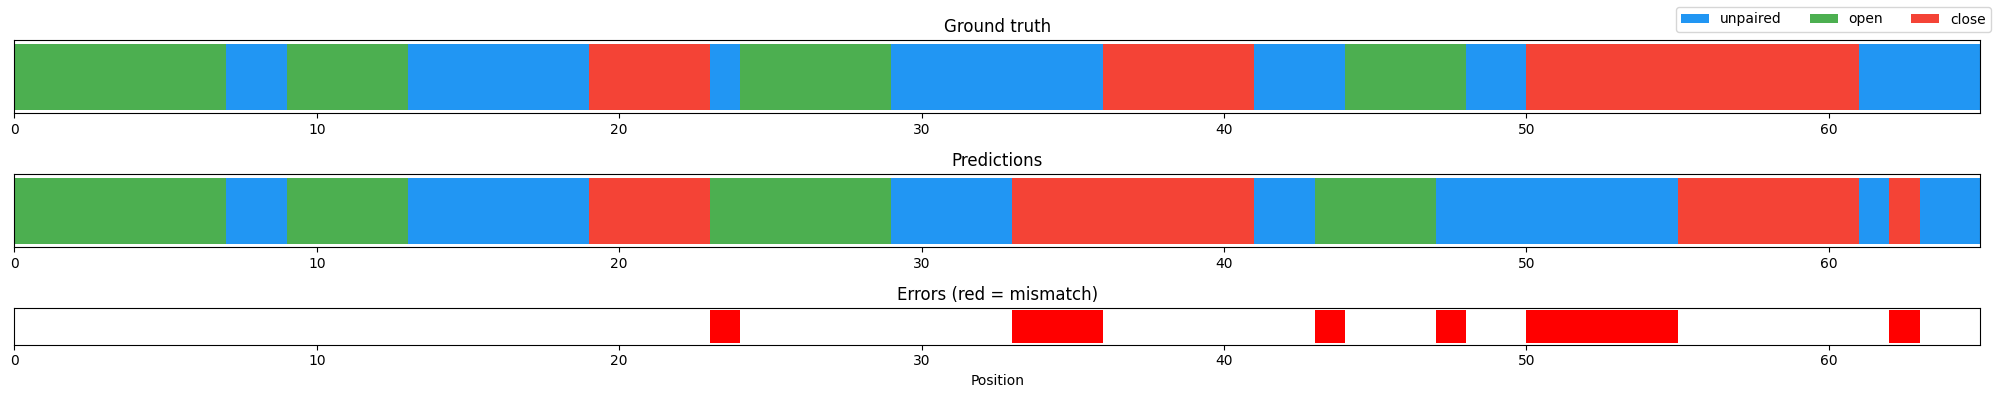

Per-position accuracy: 81.54% (53/65)


In [30]:
sample = test_ds[sample_idx]
tokens = pad_to_max_len(sample['tokens']).to(device)
L = sample['length'].item()
mask = (torch.arange(MAX_LEN).unsqueeze(0) >= sample['length']).to(device)

with torch.no_grad():
    logits = model(tokens, src_key_padding_mask=mask)
preds = logits.argmax(1).squeeze().cpu()[:, :L].argmax(0).numpy() if False else logits.argmax(1).squeeze().cpu()[:L].numpy()
labels = sample['labels'][:L].numpy()

label_names = {0: 'unpaired', 1: 'open', 2: 'close'}
colors = {0: '#2196F3', 1: '#4CAF50', 2: '#F44336'}

fig, axes = plt.subplots(3, 1, figsize=(20, 4), gridspec_kw={'height_ratios': [1, 1, 0.5]})

for i in range(L):
    axes[0].barh(0, 1, left=i, color=colors[labels[i]], edgecolor='none')
axes[0].set_xlim(0, L); axes[0].set_yticks([]); axes[0].set_title('Ground truth')

for i in range(L):
    axes[1].barh(0, 1, left=i, color=colors[preds[i]], edgecolor='none')
axes[1].set_xlim(0, L); axes[1].set_yticks([]); axes[1].set_title('Predictions')

for i in range(L):
    axes[2].barh(0, 1, left=i, color='red' if preds[i] != labels[i] else 'white', edgecolor='none')
axes[2].set_xlim(0, L); axes[2].set_yticks([])
axes[2].set_title('Errors (red = mismatch)')
axes[2].set_xlabel('Position')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[k], label=v) for k, v in label_names.items()]
fig.legend(handles=legend_elements, loc='upper right', ncol=3)
plt.tight_layout()
plt.show()

acc = (preds == labels).mean()
print(f'Per-position accuracy: {acc:.2%} ({(preds == labels).sum()}/{L})')

## 6. Заключегте

Эта модель показала себя чуть лучше на этом датасете. Возможно это связано и со структурой днк, где локальная связанность важднее.

Однако все равно было не очевидно, ведь нужно было прдесказывать как открывающие так и закрывающие пары, которые могут быть далеко друг от 
друга

Так-же на мой взгляд, здесь было самое наглядно интерпретируемое усредненное внимание, среди всех моделей на этом датасете.